# 20. 생성기 특징 공간 시각화: PCA와 UMAP

## 실험 질문

18-B·19번의 Strict Balanced 조건에서도 12종 생성기 식별 성능이 높았다. 이 노트북은 **분류기가 사용한 고차원 특징 공간에서 생성기별 음악이 어떤 구조로 놓이는지** PCA와 UMAP으로 확인한다.

| 비교 대상 | 곡 하나의 표현 |
|---|---|
| Handcrafted | 10초 구간별 266개 음향 특징을 곡 단위로 평균한 266차원 벡터 |
| Frozen MERT | MERT-v1-95M Layer 10 구간 임베딩을 곡 단위로 평균한 768차원 벡터 |

## 데이터와 그림의 단위

- Strict Balanced 전체: `119개 원곡 × 12개 생성기 = 1,428곡`
- Train: 생성기당 83곡, 총 996곡
- Validation: 생성기당 17곡, 총 204곡
- Test 시각화: 생성기당 19곡, 총 228곡
- **점 하나는 Test 음악 한 곡**, 색은 실제 생성기를 뜻한다.
- 같은 `original_audio`의 12개 생성 버전은 모두 같은 split에 배정하여 원곡이 Train과 Test에 동시에 나타나는 누수를 막는다.
- StandardScaler·PCA·UMAP은 Train에서만 학습하고 Test에는 변환만 적용한다.

> PCA와 UMAP은 분류기가 아니다. 두 그림은 특징 공간을 이해하기 위한 보조 시각화이며, 생성기 식별 성능은 18·19번의 지표와 혼동행렬로 판단한다.

## 0. UMAP 의존성 확인

이 Markdown 셀은 실행하지 않는다. 아래 라이브러리 셀에서 `umap`을 불러오지 못할 때만 새 코드 셀에서 `%pip install -q umap-learn`을 한 번 실행하고 커널을 재시작한다. 이미 설치돼 있다면 바로 다음 셀로 진행한다.

## 1. 라이브러리와 입력 경로

다음 셀은 분석에 필요한 표·배열·시각화 라이브러리와 네 가지 입력을 읽는다.

1. 10초 구간 메타데이터
2. 266차원 Handcrafted 특징
3. 13개 level의 MERT 캐시
4. 18-B에서 고정한 Strict Balanced 곡 목록

`NUMBA_CACHE_DIR`는 UMAP이 사용할 임시 컴파일 캐시 위치다. 분석 데이터나 결과에는 영향을 주지 않는다.

In [1]:
from pathlib import Path
import os
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

os.environ.setdefault("NUMBA_CACHE_DIR", str(Path(tempfile.gettempdir()) / "numba_cache"))

try:
    import umap
except ImportError:
    raise ImportError(
        "umap-learn이 없습니다. 새 주피터 코드 셀에서 "
        "`%pip install -q umap-learn` 실행 후 커널을 재시작하세요."
    )

PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "data").is_dir() and (p / "results").is_dir()),
    Path.cwd().resolve(),
)

SEGMENT_PATH = (
    PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"
)
FEATURE_PATH = (
    PROJECT_ROOT / "data/processed/features/handcrafted_features_10s.csv"
)
MERT_PATH = (
    PROJECT_ROOT / "data/processed/mert/mert95m_v2_layers_float16.npy"
)
STRICT_TRACKS_PATH = (
    PROJECT_ROOT
    / "results/generator_attribution/balanced_controlled/strict_selected_tracks.csv"
)

RESULT_DIR = (
    PROJECT_ROOT / "results/generator_fingerprint_visualization"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MERT_LAYER = 10
RANDOM_STATE = 42

segments = pd.read_csv(SEGMENT_PATH).reset_index(drop=True)
features = pd.read_csv(FEATURE_PATH)
mert_cache = np.load(MERT_PATH, mmap_mode="r")
strict_tracks = pd.read_csv(STRICT_TRACKS_PATH)

print("Segments      :", len(segments))
print("Features      :", len(features))
print("MERT cache    :", mert_cache.shape)
print("Strict tracks :", len(strict_tracks))

assert len(segments) == 10077
assert len(features) == 10077
assert mert_cache.shape == (10077, 13, 768)
assert len(strict_tracks) == 1428

print("Input QC PASS: True")

Segments      : 10077
Features      : 10077
MERT cache    : (10077, 13, 768)
Strict tracks : 1428
Input QC PASS: True


**실행 결과.** Segment와 feature는 각각 10,077행, MERT cache는 `[10077, 13, 768]`, strict track은 1,428개로 확인됐다. 입력 QC를 통과했다.

**입력 QC 요약**

- 구간 메타데이터와 Handcrafted 특징: 각각 10,077행
- MERT 캐시: `(10,077, 13, 768)`
- Strict Balanced 곡 목록: 1,428곡

이 단계는 이미 저장된 특징을 읽기만 한다. MERT를 다시 실행하거나 분류기를 재학습하지 않는다.

## 2. 생성기 색상 고정

PCA와 UMAP 네 그림에서 같은 생성기가 항상 같은 색으로 보이도록 12개 생성기의 색을 고정한다.

- 점 1개: Test 음악 1곡
- 색: 실제 생성기
- 같은 색 점이 가까움: 해당 표현에서 두 곡이 비슷하게 놓였다는 뜻
- 축의 숫자: 음질, 정확도, 생성 확률이 아님

색은 정답 라벨을 표시할 뿐이며 PCA·UMAP 계산에는 사용되지 않는다.

In [2]:
GENERATOR_COLORS = {
    "acestep":     "#1f77b4",
    "audioldm":    "#ff7f0e",
    "brev":        "#2ca02c",
    "diffrhythm":  "#d62728",
    "elevenlabs":  "#9467bd",
    "mubert":      "#8c564b",
    "musicgen":    "#e377c2",
    "producer":    "#7f7f7f",
    "songgen":     "#bcbd22",
    "stableaudio": "#17becf",
    "suno":        "#393b79",
    "udio":        "#e6550d",
}

print("Generator colors:", len(GENERATOR_COLORS))
assert len(GENERATOR_COLORS) == 12

Generator colors: 12


**실행 결과.** 12개 생성기에 서로 다른 색을 지정했고, 색상표의 항목 수도 12개임을 확인했다.

## 3. Handcrafted 곡 표현 만들기

각 10초 구간에는 스펙트럼, MFCC, RMS 등 266개 음향 특징이 있다. 같은 곡에 속한 구간들의 특징을 열별로 평균하여 **곡당 하나의 266차원 벡터**를 만든다.

In [3]:
segment_meta_cols = set(segments.columns)

extra_meta_cols = {
    "Unnamed: 0",
    "index",
    "cache_index",
    "extraction_success",
    "success",
    "error",
}

feature_cols = [
    c for c in features.columns
    if c != "segment_id"
    and c not in segment_meta_cols
    and c not in extra_meta_cols
    and not str(c).startswith("Unnamed:")
    and pd.api.types.is_numeric_dtype(features[c])
]

assert len(feature_cols) == 266

meta = segments[
    [
        "segment_id",
        "track_sample_id",
        "original_audio",
        "generator",
        "genre",
        "split",
        "label",
    ]
].copy()

merged = meta.merge(
    features[["segment_id"] + feature_cols],
    on="segment_id",
    how="inner",
    validate="one_to_one",
)

selected_ids = set(strict_tracks["track_sample_id"])

strict_seg = merged[
    merged["track_sample_id"].isin(selected_ids)
].copy()

hand_track = (
    strict_seg
    .groupby("track_sample_id", as_index=False)
    .agg(
        {
            **{
                "original_audio": "first",
                "generator": "first",
                "genre": "first",
                "split": "first",
            },
            **{c: "mean" for c in feature_cols},
        }
    )
)

print("Handcrafted track rows:", len(hand_track))
print("Feature dims:", len(feature_cols))

assert len(hand_track) == 1428
assert not hand_track[feature_cols].isna().any().any()

print("Handcrafted Track QC PASS: True")

Handcrafted track rows: 1428
Feature dims: 266
Handcrafted Track QC PASS: True


**실행 결과.** Strict 자료의 Handcrafted 표현은 1,428개 track과 266개 특징으로 구성됐다. 결측치 없이 track 단위 평균 집계가 완료됐다.

**Handcrafted QC 요약:** Strict Balanced 1,428곡이 각각 266차원 벡터로 변환됐으며 결측값이 없다. 이후 그림에는 이 가운데 Test 228곡만 표시한다.

## 4. MERT 곡 표현 만들기

각 곡의 10초 구간에서 Frozen MERT **Layer 10**의 768차원 임베딩을 읽고 평균하여 곡당 하나의 벡터를 만든다. Layer 10은 19번 실험에서 Validation 성능으로 선택된 값이며, 이 노트북에서 Test를 보고 다시 선택하지 않는다.

In [4]:
segments = segments.copy()
segments["cache_index"] = np.arange(len(segments))

strict_mert_seg = segments[
    segments["track_sample_id"].isin(selected_ids)
].copy()

mert_rows = []

for track_id, group in strict_mert_seg.groupby("track_sample_id"):
    idx = group["cache_index"].to_numpy(dtype=int)

    emb = np.asarray(
        mert_cache[idx, BEST_MERT_LAYER, :],
        dtype=np.float32,
    ).mean(axis=0)

    first = group.iloc[0]

    mert_rows.append({
        "track_sample_id": track_id,
        "original_audio": first["original_audio"],
        "generator": first["generator"],
        "genre": first["genre"],
        "split": first["split"],
        "embedding": emb,
    })

mert_track = pd.DataFrame(mert_rows)

print("MERT track rows:", len(mert_track))
print("MERT dims:", len(mert_track.iloc[0]["embedding"]))
print("Layer:", BEST_MERT_LAYER)

assert len(mert_track) == 1428
assert len(mert_track.iloc[0]["embedding"]) == 768

print("MERT Track QC PASS: True")

MERT track rows: 1428
MERT dims: 768
Layer: 10
MERT Track QC PASS: True


**실행 결과.** Layer 10 MERT 표현은 1,428개 track과 768차원으로 구성됐다. Track 수와 임베딩 차원 검사를 통과했다.

**MERT QC 요약:** Strict Balanced 1,428곡이 각각 768차원 벡터로 변환됐다. Handcrafted와 동일한 곡·분할을 사용하므로 두 표현의 시각화를 같은 조건에서 비교할 수 있다.

## 5. Strict Balanced 구성 재확인

전체 데이터에서는 생성기마다 곡 수와 원곡 구성이 다를 수 있다. Strict Balanced는 12개 생성기에 모두 존재하는 원곡만 남기고 `원곡 × 생성기`마다 정확히 한 곡을 선택하여 다음 두 혼란 요인을 줄인다.

- 생성기별 표본 수 차이
- 특정 생성기에만 존재하는 원곡 구성 차이
- 같은 원곡이 Train과 Test에 동시에 들어가는 source leakage

각 원곡의 12개 생성 버전은 모두 같은 split에 둔다. 다음 셀은 두 표현 모두에서 각 생성기가 Train 83곡·Validation 17곡·Test 19곡인지 검사한다.

In [5]:
for name, df in [
    ("Handcrafted", hand_track),
    ("MERT", mert_track),
]:
    print("\n", name)

    table = pd.crosstab(
        df["generator"],
        df["split"],
    )

    display(table)

    assert table["train"].nunique() == 1
    assert table["val"].nunique() == 1
    assert table["test"].nunique() == 1
    assert int(table["train"].iloc[0]) == 83
    assert int(table["val"].iloc[0]) == 17
    assert int(table["test"].iloc[0]) == 19

print("Strict Balance QC PASS: True")


 Handcrafted


split,test,train,val
generator,,,
acestep,19,83,17
audioldm,19,83,17
brev,19,83,17
diffrhythm,19,83,17
elevenlabs,19,83,17
mubert,19,83,17
musicgen,19,83,17
producer,19,83,17
songgen,19,83,17



 MERT


split,test,train,val
generator,,,
acestep,19,83,17
audioldm,19,83,17
brev,19,83,17
diffrhythm,19,83,17
elevenlabs,19,83,17
mubert,19,83,17
musicgen,19,83,17
producer,19,83,17
songgen,19,83,17


Strict Balance QC PASS: True


**실행 결과.** Handcrafted와 MERT 자료 모두 생성기마다 Train 83개, Validation 17개, Test 19개였다. 두 표현에서 같은 균형 구성을 사용했다.

**균형 QC 요약:** Handcrafted와 MERT 모두 생성기당 Test 19곡, 전체 228곡을 사용한다. 따라서 한 표현에만 곡이 더 많아서 군집이 달라지는 문제를 피했다.

## 6. PCA: 전역적인 선형 구조 보기

PCA는 표준화된 고차원 특징에서 **분산이 가장 큰 직선 방향 두 개(PC1·PC2)**를 찾는다. 전체적인 퍼짐과 선형 구조를 확인하는 기준선이다.

1. Train으로 StandardScaler를 학습한다.
2. Train으로 PCA 두 축을 학습한다.
3. Test에는 두 변환을 적용만 한다.

PC1·PC2는 여러 원래 특징의 조합이다. 축의 양수·음수나 방향 자체를 특정 음향 속성으로 바로 해석하면 안 된다.

In [6]:
def get_representation(name):
    if name == "Handcrafted":
        train = hand_track[hand_track["split"] == "train"].reset_index(drop=True)
        test = hand_track[hand_track["split"] == "test"].reset_index(drop=True)

        X_train = train[feature_cols].to_numpy(dtype=np.float32)
        X_test = test[feature_cols].to_numpy(dtype=np.float32)

    elif name == "MERT":
        train = mert_track[mert_track["split"] == "train"].reset_index(drop=True)
        test = mert_track[mert_track["split"] == "test"].reset_index(drop=True)

        X_train = np.stack(train["embedding"].to_numpy()).astype(np.float32)
        X_test = np.stack(test["embedding"].to_numpy()).astype(np.float32)

    else:
        raise ValueError(name)

    return train, test, X_train, X_test


pca_results = {}

for name in ["Handcrafted", "MERT"]:
    train, test, X_train, X_test = get_representation(name)

    scaler = StandardScaler()

    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)

    pca = PCA(
        n_components=2,
        random_state=RANDOM_STATE,
    )

    pca.fit(X_train_z)

    coords = pca.transform(X_test_z)

    pca_results[name] = {
        "train": train,
        "test": test,
        "X_test_z": X_test_z,
        "coords": coords,
        "explained": pca.explained_variance_ratio_,
    }

    print(
        name,
        "explained variance:",
        np.round(pca.explained_variance_ratio_, 4),
        "sum=",
        round(float(pca.explained_variance_ratio_.sum()), 4),
    )

Handcrafted explained variance: [0.2658 0.094 ] sum= 0.3598
MERT explained variance: [0.0949 0.0731] sum= 0.168


**실행 결과.** PCA 첫 두 축의 설명분산 합은 Handcrafted 0.3598, MERT 0.1680이었다. PCA는 Train에 맞추고 Test 228개 track에 변환만 적용했다.

**PCA가 두 축에 보존한 분산**

- Handcrafted: PC1 26.58% + PC2 9.40% = **35.98%**
- MERT: PC1 9.49% + PC2 7.31% = **16.80%**

특히 MERT의 두 주성분이 설명하지 못한 **표준화 특징 분산은 약 83.2%**다. 점들이 겹쳐도 원래 768차원에서 생성기를 구분할 정보가 없다는 뜻은 아니다.

## 7. PCA Test 그림

그림의 `Dimension 1`과 `Dimension 2`는 각각 PC1과 PC2다. 각 점은 Test 곡이며 색은 실제 생성기다. 같은 색이 독립된 영역을 만들면 두 주성분만으로도 생성기 구조가 보인다는 뜻이다. 서로 다른 색이 겹치면 **이 두 선형 축만으로는** 구분이 어렵다는 뜻이다.

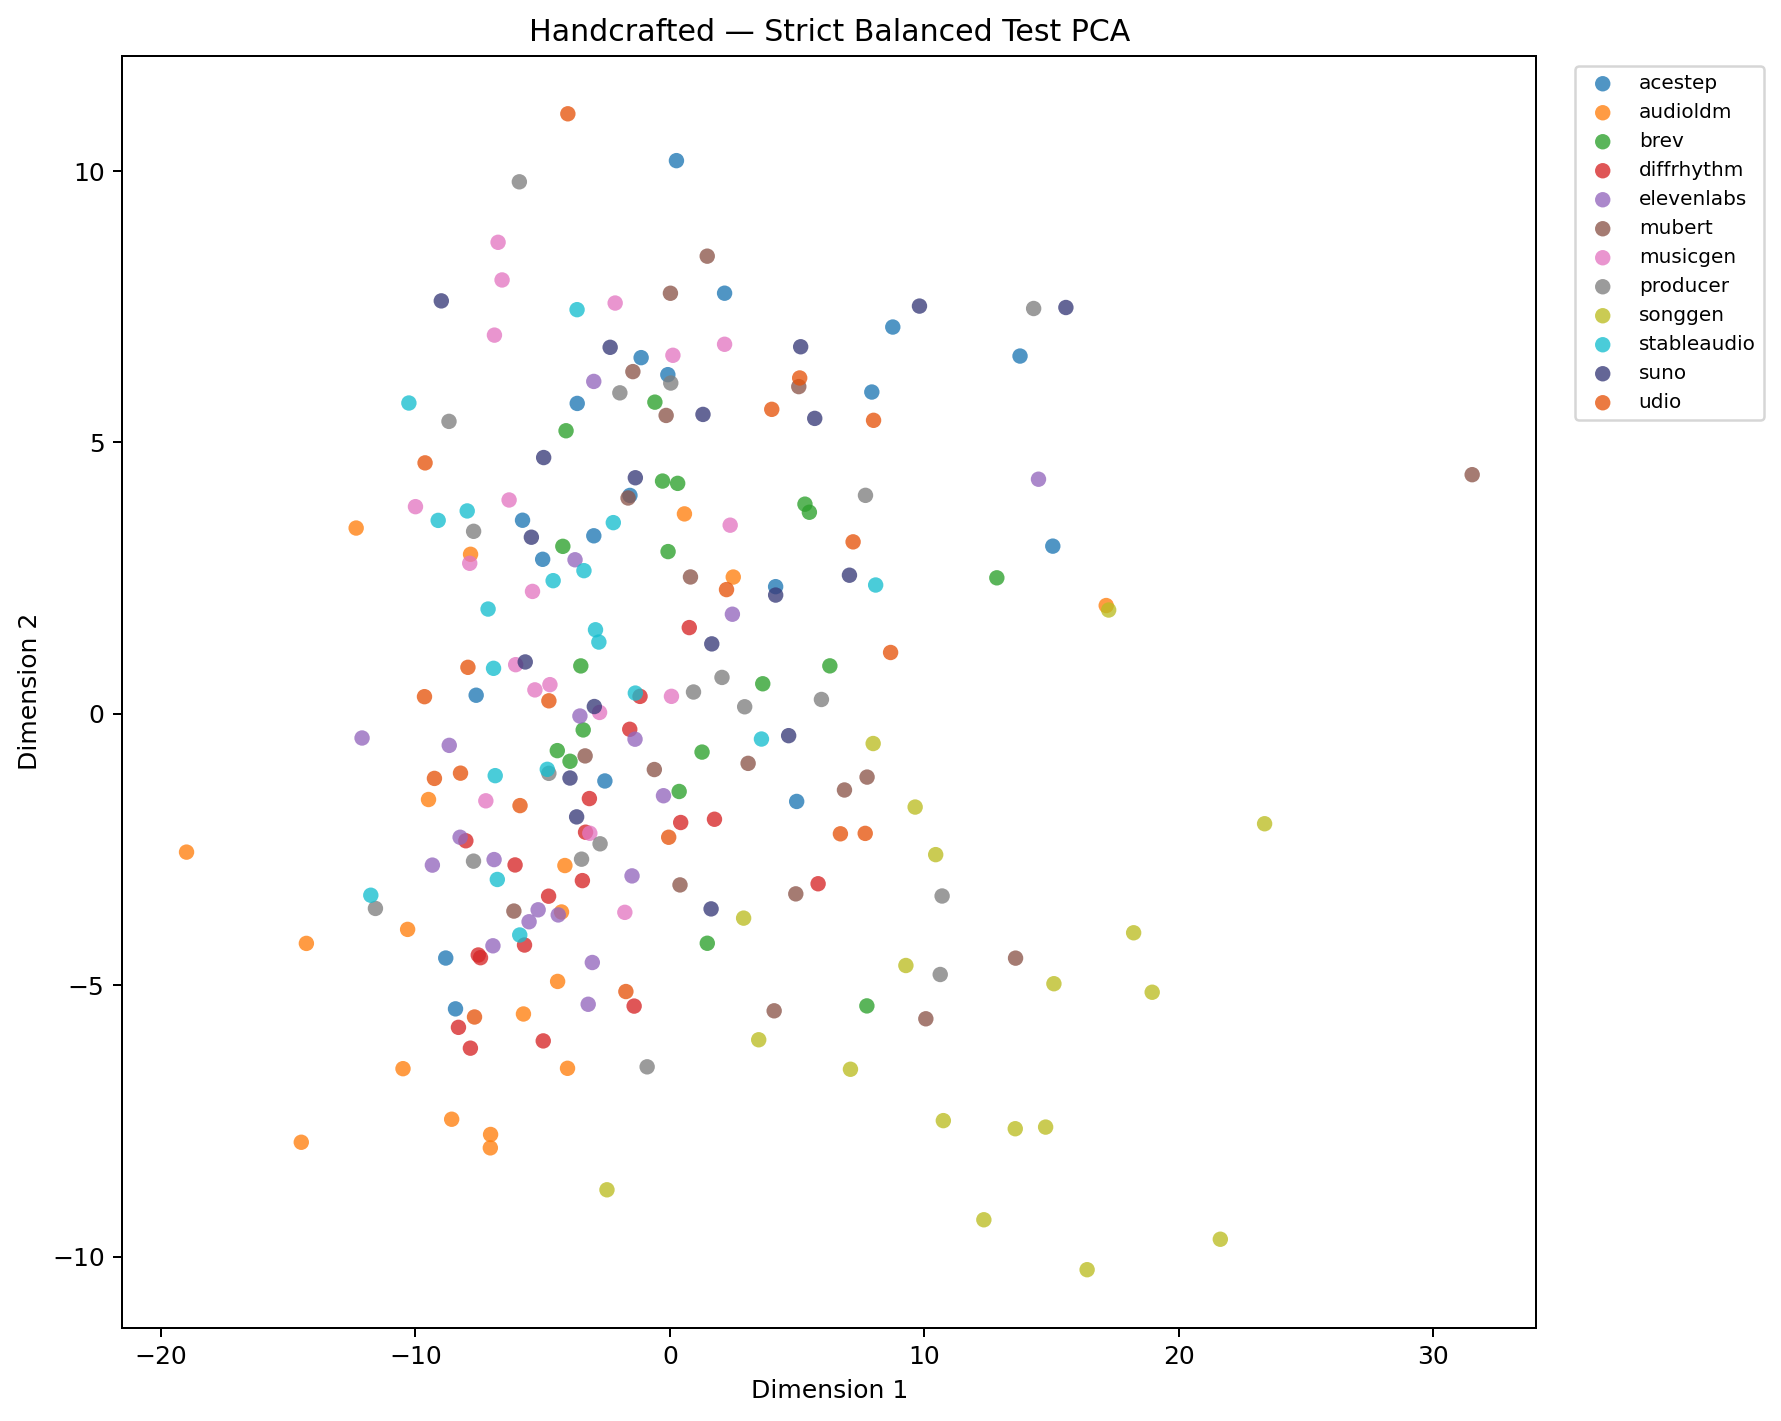

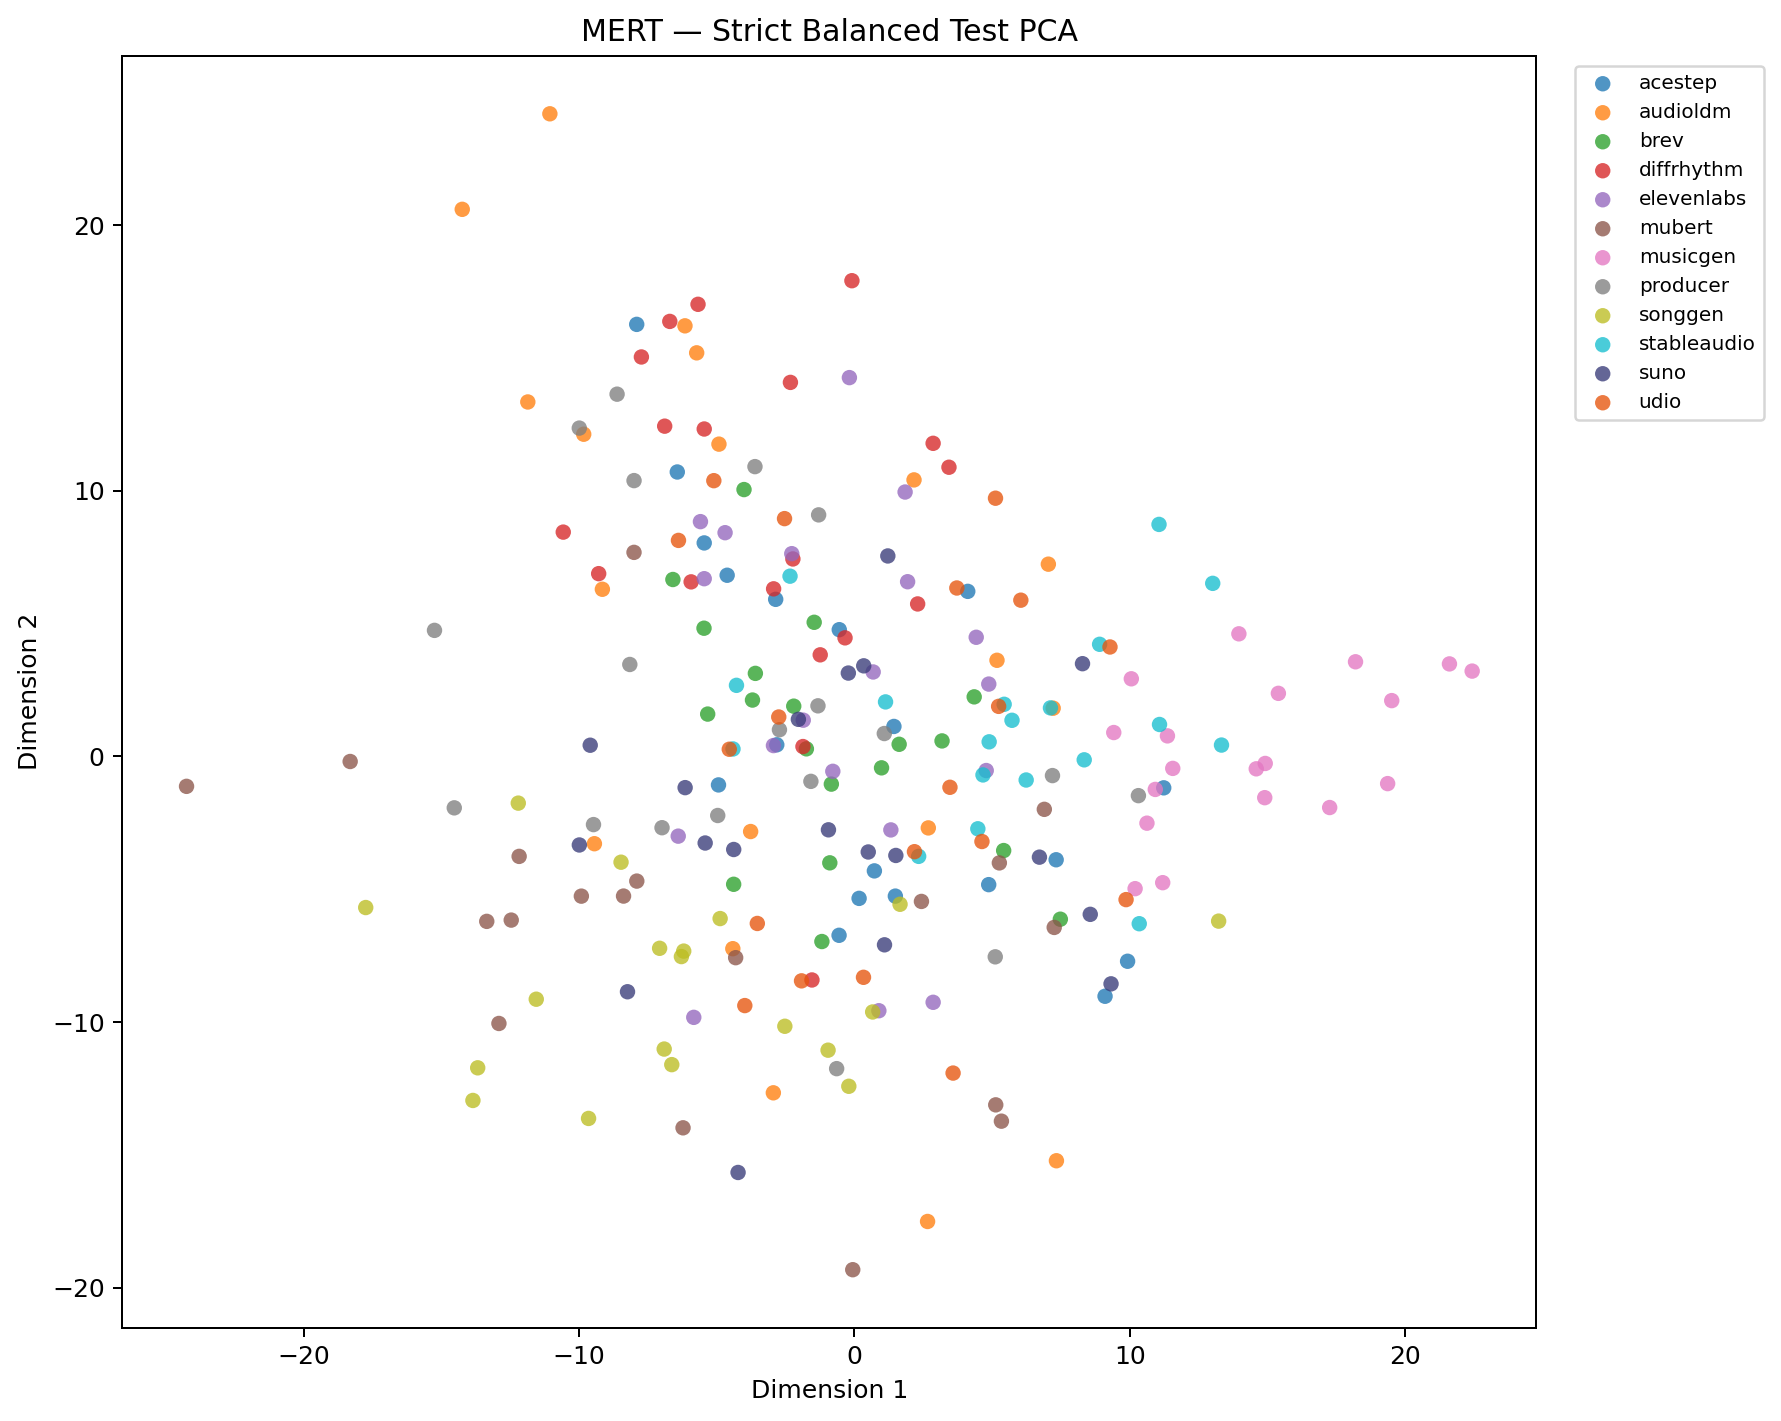

In [7]:
def plot_2d(coords, labels, title, save_path):
    fig, ax = plt.subplots(figsize=(10, 8))

    classes = sorted(pd.Series(labels).unique())

    for cls in classes:
        mask = np.asarray(labels) == cls

        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            label=cls,
            color=GENERATOR_COLORS.get(cls, "#000000"),
            alpha=0.78,
            s=38,
            edgecolors="none",
        )

    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title(title)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        frameon=True,
    )

    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


for name in ["Handcrafted", "MERT"]:
    r = pca_results[name]

    plot_2d(
        r["coords"],
        r["test"]["generator"],
        f"{name} — Strict Balanced Test PCA",
        RESULT_DIR / f"pca_{name.lower()}_strict_test.png",
    )

**실행 결과.** Handcrafted와 MERT의 Test PCA 산점도를 생성해 각각 PNG 파일로 저장했다. 이 셀은 그림 출력이 중심이라 별도 표는 없다.

### PCA 결과 해석

- Handcrafted와 MERT 모두 여러 색이 넓게 겹쳐 12개 생성기가 두 개의 독립된 선형 축에서 완전히 분리되지는 않는다.
- Handcrafted에서는 SongGen이 오른쪽 아래로, MERT에서는 MusicGen이 오른쪽·SongGen이 아래쪽으로 치우치는 경향이 보인다.
- 이러한 방향성은 일부 구조를 보여주지만 생성기별 독립 군집을 증명하지 않는다.

PCA 그림은 손실이 큰 2차원 요약이므로 분류 성능표와 함께 읽어야 한다.

## 8. UMAP: 국소적인 비선형 이웃 구조 보기

UMAP은 원래 공간에서 가까운 곡들이 2차원에서도 가깝도록 배치하는 비선형 방법이다. PCA에서 보이지 않는 휘어진 구조나 작은 이웃 집단을 탐색한다.

- `n_neighbors=30`: 주변 30개 이웃을 기준으로 구조를 학습
- `min_dist=0.15`: 2차원에서 점이 모일 수 있는 정도
- 거리: Euclidean
- seed: 42

UMAP도 Train에서 학습하고 Test에는 변환만 적용한다. UMAP 축, 회전 방향, 군집의 절대거리와 면적에는 물리적인 의미가 없으며 설정값과 seed에 따라 모양이 달라질 수 있다.

In [8]:
umap_results = {}

for name in ["Handcrafted", "MERT"]:
    train, test, X_train, X_test = get_representation(name)

    scaler = StandardScaler()

    X_train_z = scaler.fit_transform(X_train)
    X_test_z = scaler.transform(X_test)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.15,
        metric="euclidean",
        random_state=RANDOM_STATE,
        transform_seed=RANDOM_STATE,
    )

    reducer.fit(X_train_z)
    coords = reducer.transform(X_test_z)

    umap_results[name] = {
        "train": train,
        "test": test,
        "X_test_z": X_test_z,
        "coords": coords,
    }

    print(name, "UMAP test shape:", coords.shape)

print("UMAP Transform PASS: True")

Handcrafted UMAP test shape: (228, 2)
MERT UMAP test shape: (228, 2)
UMAP Transform PASS: True


**실행 결과.** UMAP으로 변환한 Test 좌표는 두 표현 모두 `(228, 2)`였다. Train 적합과 Test 변환 과정이 정상적으로 끝났다.

**UMAP 변환 요약:** 두 표현 모두 동일한 Test 228곡을 `(228, 2)` 좌표로 변환했다. 좌표값 자체보다 가까운 이웃과 색의 섞임 정도를 본다.

## 9. UMAP Test 그림

그림의 `Dimension 1`과 `Dimension 2`는 물리적 단위가 없는 UMAP 상대 좌표다. 점과 색의 의미는 PCA와 같다. 다만 PCA와 UMAP의 좌표 체계는 서로 다르므로 두 그림의 x·y 숫자나 좌우 위치를 직접 비교하지 않는다.

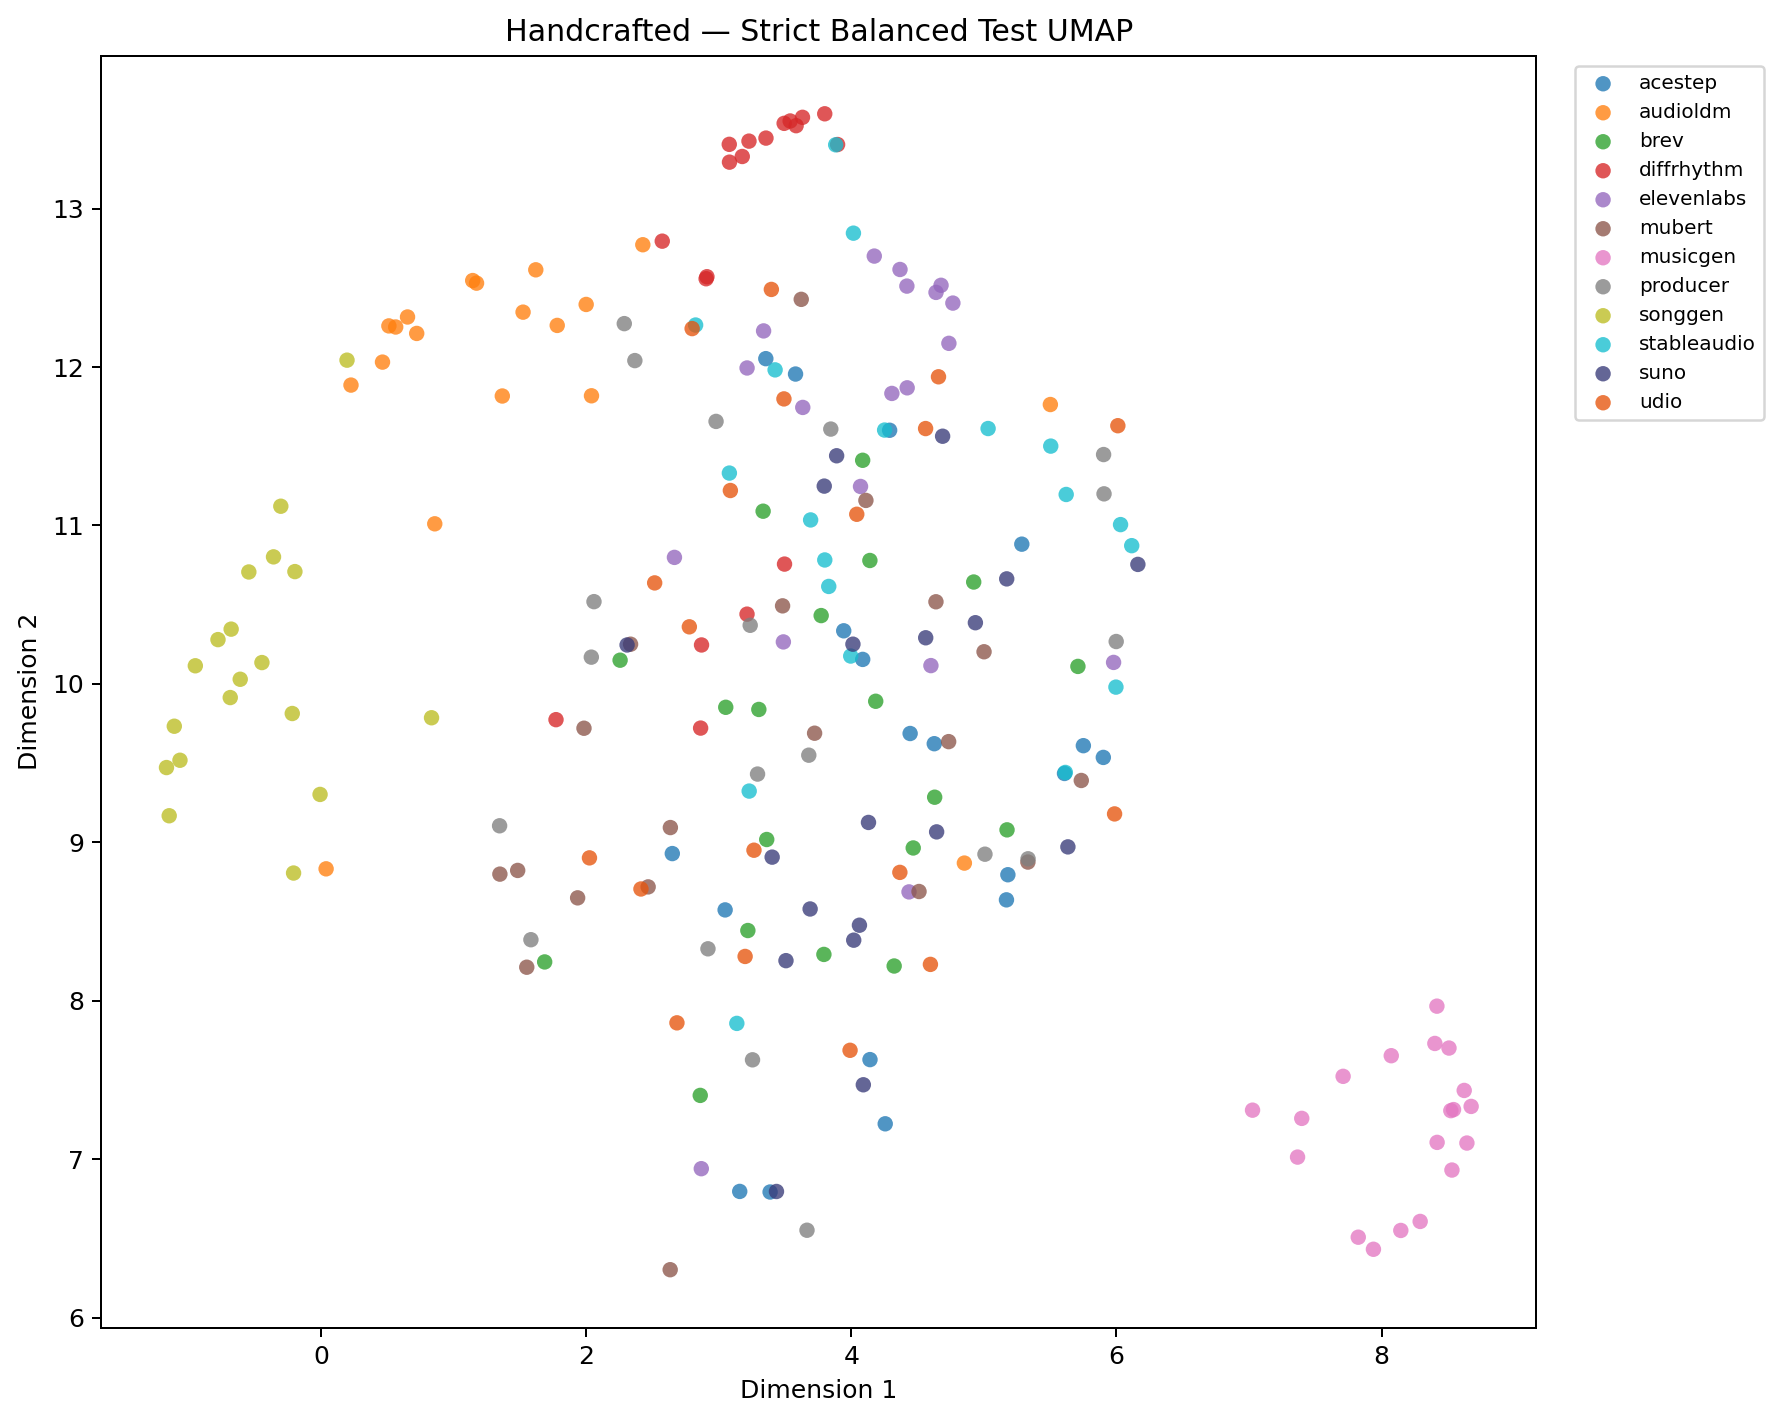

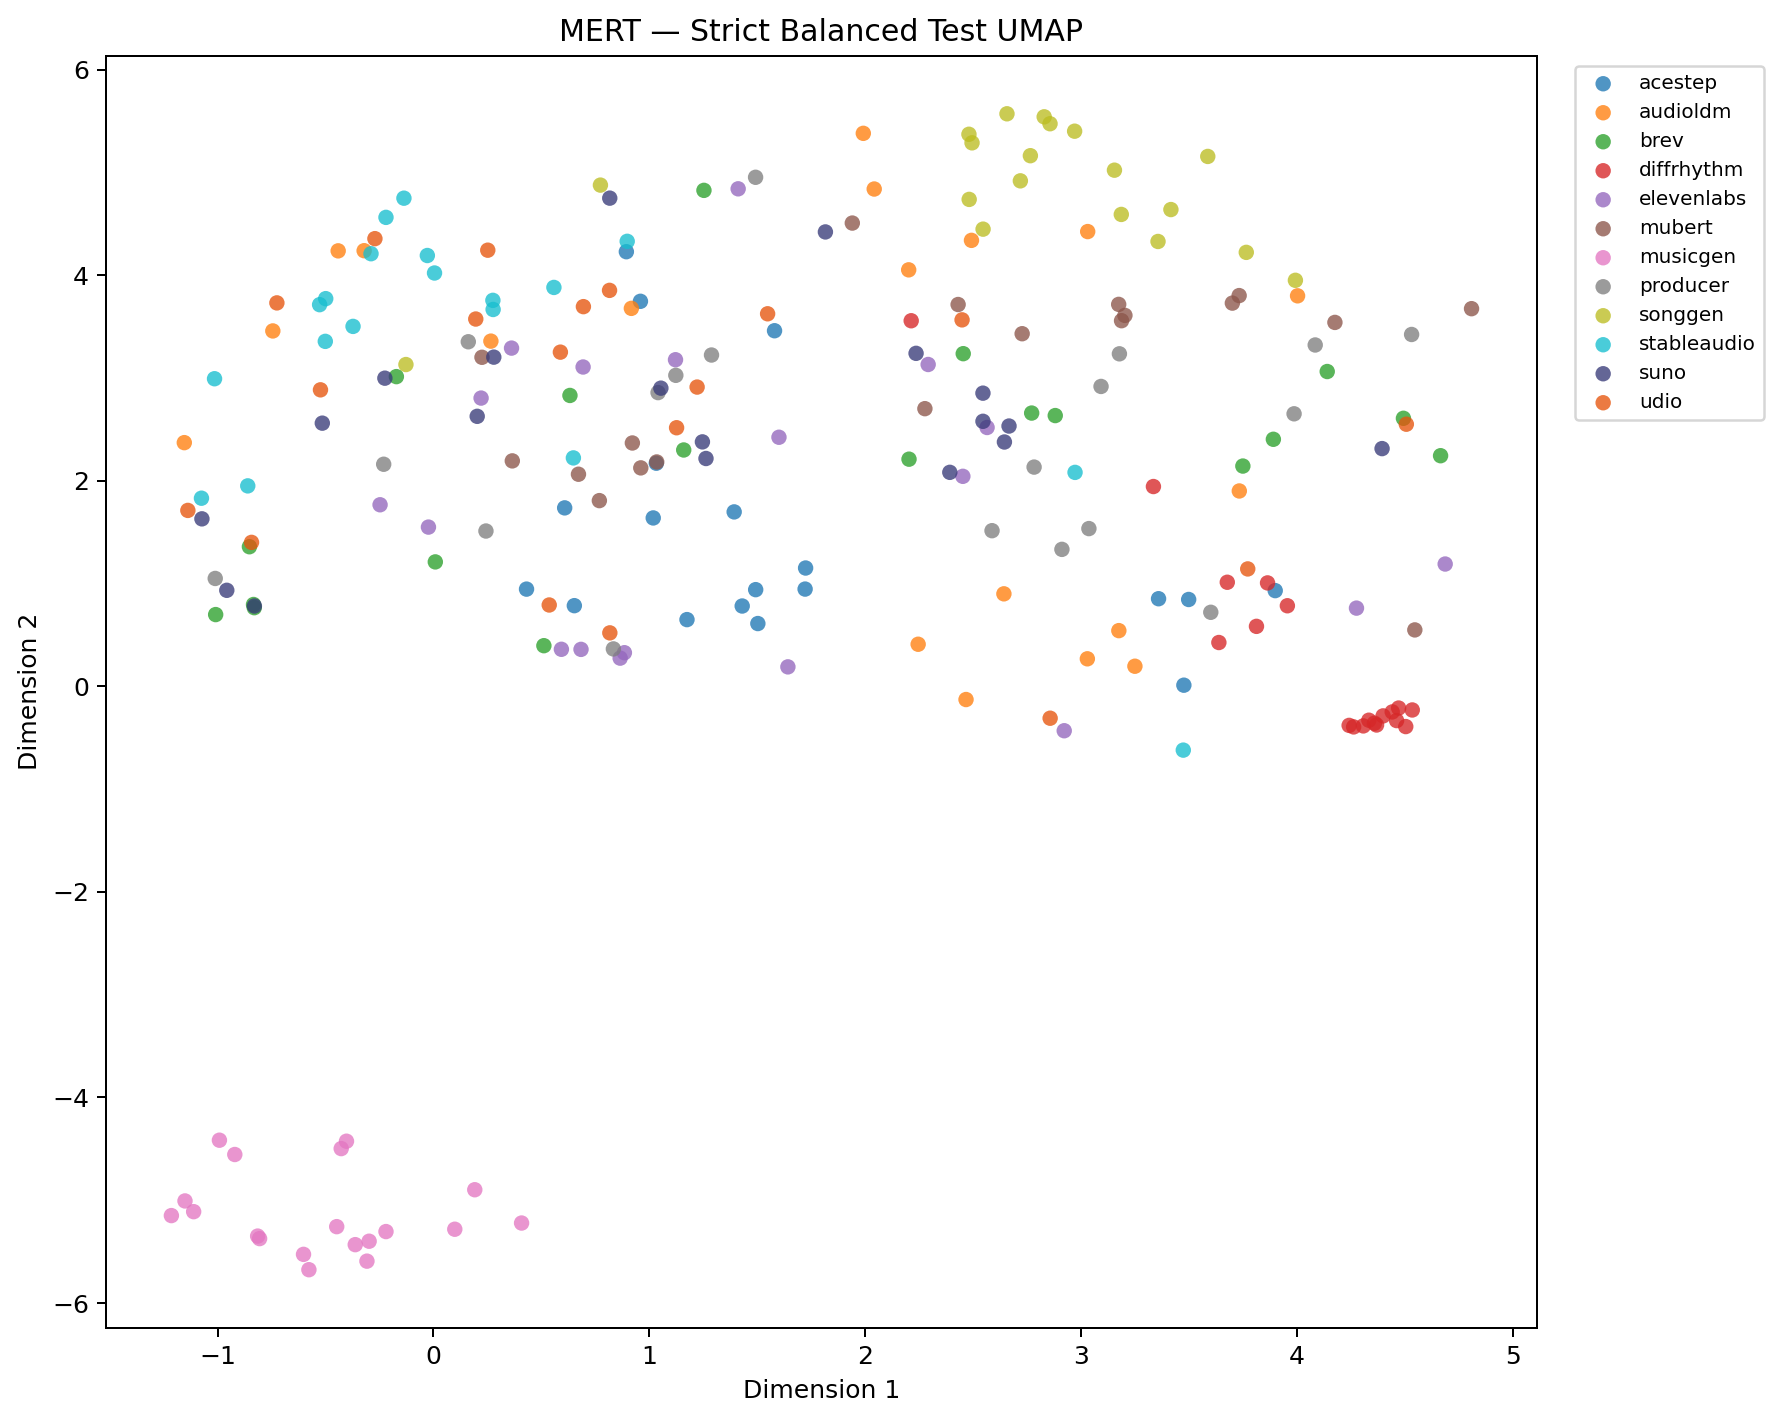

In [9]:
for name in ["Handcrafted", "MERT"]:
    r = umap_results[name]

    plot_2d(
        r["coords"],
        r["test"]["generator"],
        f"{name} — Strict Balanced Test UMAP",
        RESULT_DIR / f"umap_{name.lower()}_strict_test.png",
    )

**실행 결과.** Handcrafted와 MERT의 Test UMAP 산점도를 생성해 각각 PNG 파일로 저장했다.

### UMAP 결과 해석

- Handcrafted에서는 MusicGen·SongGen·DiffRhythm 일부가 상대적으로 모이지만 나머지 생성기는 크게 섞인다.
- MERT에서는 MusicGen이 비교적 분리되고 DiffRhythm·SongGen의 일부 국소 구조가 보이지만, 여러 생성기는 여전히 겹친다.
- 보이는 작은 섬은 시각적 경향이며 정확도나 통계적 유의성을 뜻하지 않는다.

UMAP에서 분리돼 보인다는 사실만으로 새 음악도 같은 위치에 놓인다고 보장할 수 없다.

## 10. 생성기 Silhouette 점수

Silhouette는 같은 라벨끼리 얼마나 가깝고 다른 라벨과 얼마나 떨어져 있는지 측정한다.

- 1에 가까움: 각 생성기가 조밀하고 서로 잘 분리됨
- 0 부근: 생성기들이 겹침
- 평균이 음수: 평균적으로 자기 생성기보다 더 가까운 다른 생성기 군집이 있는 구조

표준화된 원공간, PCA 2차원, UMAP 2차원을 따로 계산한다. 이 점수는 **둥글고 조밀한 군집 구조**를 보는 지표이며 분류 정확도와 같은 값이 아니다.

In [10]:
rows = []

for name in ["Handcrafted", "MERT"]:
    labels = pca_results[name]["test"]["generator"].to_numpy()

    spaces = {
        "standardized_original": pca_results[name]["X_test_z"],
        "pca_2d": pca_results[name]["coords"],
        "umap_2d": umap_results[name]["coords"],
    }

    for space_name, X in spaces.items():
        rows.append({
            "representation": name,
            "space": space_name,
            "generator_silhouette": silhouette_score(
                X,
                labels,
                metric="euclidean",
            ),
        })

silhouette_df = pd.DataFrame(rows)

display(silhouette_df.round(4))

,representation,space,generator_silhouette
0,Handcrafted,standardized_original,-0.0183
1,Handcrafted,pca_2d,-0.1814
2,Handcrafted,umap_2d,0.0344
3,MERT,standardized_original,0.0164
4,MERT,pca_2d,-0.1445
5,MERT,umap_2d,0.0016


**실행 결과.** 원공간 generator silhouette는 Handcrafted -0.0183, MERT 0.0164였다. UMAP 2차원에서는 각각 0.0344와 0.0016으로, 뚜렷한 전역 군집은 나타나지 않았다.

### Silhouette 결과 해석

| 표현 | 표준화 원공간 | PCA 2D | UMAP 2D |
|---|---:|---:|---:|
| Handcrafted | -0.0183 | -0.1814 | 0.0344 |
| MERT | 0.0164 | -0.1445 | 0.0016 |

모든 값이 0 근처이거나 음수다. 즉, 12개 생성기가 각각 하나의 조밀한 전역 군집을 만들지는 않는다. Handcrafted UMAP 점수가 MERT보다 높다는 이유만으로 Handcrafted 분류 성능이 더 좋다고 해석하면 안 된다.

## 11. 생성기 구조와 장르 구조 비교

같은 Test 곡의 표준화된 고차원 원공간에서 `generator` 라벨과 `genre` 라벨의 Silhouette를 비교한다. 생성기별로 보이는 구조가 실제로는 장르 차이였는지 살펴보는 보조 분석이다.

다만 생성기는 12개 균형 집단(각 19곡)이고 장르는 3개 불균형 집단(Rock 84곡, Electronic 84곡, Pop 60곡)이다. 군집 수와 크기가 달라 두 Silhouette를 공정한 일대일 성능 비교로 해석하지 않는다.

In [11]:
rows = []

for name in ["Handcrafted", "MERT"]:
    test = pca_results[name]["test"]
    X = pca_results[name]["X_test_z"]

    generator_s = silhouette_score(
        X,
        test["generator"].to_numpy(),
    )

    genre_s = silhouette_score(
        X,
        test["genre"].to_numpy(),
    )

    rows.append({
        "representation": name,
        "generator_silhouette": generator_s,
        "genre_silhouette": genre_s,
        "generator_minus_genre": generator_s - genre_s,
    })

generator_vs_genre = pd.DataFrame(rows)

display(generator_vs_genre.round(4))

,representation,generator_silhouette,genre_silhouette,generator_minus_genre
0,Handcrafted,-0.0183,-0.0169,-0.0014
1,MERT,0.0164,-0.0188,0.0352


**실행 결과.** 원공간에서 generator와 genre silhouette의 차이는 Handcrafted -0.0014, MERT 0.0352였다. MERT에서는 generator 기준 값이 genre 기준보다 조금 높았다.

### 생성기와 장르 비교 결과

| 표현 | 생성기 Silhouette | 장르 Silhouette | 생성기 − 장르 |
|---|---:|---:|---:|
| Handcrafted | -0.0183 | -0.0169 | -0.0014 |
| MERT | 0.0164 | -0.0188 | +0.0352 |

이 Test 표본에서 MERT의 생성기 라벨 보조 점수가 장르보다 0.0352 높았다. 하지만 라벨별 군집 수와 크기가 다르고 절대값도 작으므로, 생성기 구조가 장르보다 일반적으로 더 강하다는 결론이나 뚜렷한 생성기 군집의 증거로 사용하지 않는다.

## 12. 결과 저장과 최종 QC

다음 셀은 아래 파일을 `results/generator_fingerprint_visualization/`에 저장한다.

- PCA·UMAP 좌표 CSV 4개: Test 곡 ID, 원곡, 생성기, 장르, 2차원 좌표
- PCA·UMAP 그림 4개
- 생성기 Silhouette 표
- 생성기·장르 Silhouette 비교표

마지막 QC는 Strict 곡 수, 특징 차원, MERT layer, Test 행 수, 지표 행 수와 네 그림의 존재를 확인한다.

> 이 최종 분석 노트북을 다시 실행하면 위 10개 파생 산출물을 같은 경로에 재생성한다.

In [12]:
silhouette_df.to_csv(
    RESULT_DIR / "generator_silhouette_scores.csv",
    index=False,
    encoding="utf-8-sig",
)

generator_vs_genre.to_csv(
    RESULT_DIR / "generator_vs_genre_silhouette.csv",
    index=False,
    encoding="utf-8-sig",
)

for name in ["Handcrafted", "MERT"]:
    for method, results in [
        ("pca", pca_results),
        ("umap", umap_results),
    ]:
        out_df = results[name]["test"][
            [
                "track_sample_id",
                "original_audio",
                "generator",
                "genre",
                "split",
            ]
        ].copy()

        out_df["x"] = results[name]["coords"][:, 0]
        out_df["y"] = results[name]["coords"][:, 1]

        out_df.to_csv(
            RESULT_DIR / f"{method}_{name.lower()}_strict_test.csv",
            index=False,
            encoding="utf-8-sig",
        )

expected_output_files = [
    RESULT_DIR / "generator_silhouette_scores.csv",
    RESULT_DIR / "generator_vs_genre_silhouette.csv",
    *[
        RESULT_DIR / f"{method}_{name.lower()}_strict_test.csv"
        for name in ["Handcrafted", "MERT"]
        for method in ["pca", "umap"]
    ],
    *[
        RESULT_DIR / f"{method}_{name.lower()}_strict_test.png"
        for name in ["Handcrafted", "MERT"]
        for method in ["pca", "umap"]
    ],
]
output_files_ok = all(
    path.is_file() and path.stat().st_size > 0
    for path in expected_output_files
)

qc = pd.DataFrame({
    "check": [
        "strict_tracks",
        "handcrafted_dims",
        "mert_dims",
        "best_mert_layer",
        "hand_test_rows",
        "mert_test_rows",
        "silhouette_rows",
        "pca_pngs",
        "umap_pngs",
        "all_10_output_files_exist_and_nonempty",
    ],
    "value": [
        len(strict_tracks),
        len(feature_cols),
        768,
        BEST_MERT_LAYER,
        len(pca_results["Handcrafted"]["test"]),
        len(pca_results["MERT"]["test"]),
        len(silhouette_df),
        (
            RESULT_DIR / "pca_handcrafted_strict_test.png"
        ).exists()
        and (
            RESULT_DIR / "pca_mert_strict_test.png"
        ).exists(),
        (
            RESULT_DIR / "umap_handcrafted_strict_test.png"
        ).exists()
        and (
            RESULT_DIR / "umap_mert_strict_test.png"
        ).exists(),
        output_files_ok,
    ],
})

display(qc)

core_qc_pass = (
    len(strict_tracks) == 1428
    and len(feature_cols) == 266
    and BEST_MERT_LAYER == 10
    and len(pca_results["Handcrafted"]["test"]) == 228
    and len(pca_results["MERT"]["test"]) == 228
    and len(silhouette_df) == 6
    and output_files_ok
)

print("===== FINAL RESULT =====")
print(
    "Generator Fingerprint Visualization Core QC PASS:",
    core_qc_pass,
)

,check,value
0,strict_tracks,1428
1,handcrafted_dims,266
2,mert_dims,768
3,best_mert_layer,10
4,hand_test_rows,228
5,mert_test_rows,228
6,silhouette_rows,6
7,pca_pngs,True
8,umap_pngs,True
9,all_10_output_files_exist_and_nonempty,True


===== FINAL RESULT =====
Generator Fingerprint Visualization Core QC PASS: True


**실행 결과.** 좌표와 silhouette 표, PCA·UMAP 그림 등 예상한 10개 파일이 모두 생성됐고 비어 있지 않았다. 최종 QC는 통과했다.

## 결과 정리

Strict balanced Test 228개 track을 Handcrafted와 MERT 공간에서 비교했다. PCA 첫 두 축의 설명분산 합은 각각 **0.3598**과 **0.1680**이었다. 원공간 generator silhouette는 Handcrafted **-0.0183**, MERT **0.0164**로 두 표현 모두 뚜렷한 전역 군집을 보이지 않았다.

따라서 PCA·UMAP 그림만으로 생성기 분류 성능을 판단하지 않고, 18번과 19번 노트북의 Test 지표와 혼동행렬을 함께 본다. 시각화 결과는 119개 공통 원곡과 현재 UMAP 설정에 한정된다.

좌표표와 그림을 포함한 예상 파일 10개가 모두 생성됐고 QC 검사를 통과했다.
